In [265]:
# Se serve installare:
!pip install -q kagglehub[pandas-datasets]

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier

import kagglehub
from kagglehub import KaggleDatasetAdapter

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

# PARTE 1    -     DATASET STORICO (ANNI 2015 - 2017)

Cella 1 - caricamento dataset

In [266]:
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jessemostipak/hotel-booking-demand",
    "hotel_bookings.csv"
)

print(df.shape)
df.head()

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Preprocessing iniziale (primo recipe in Dataiku)

Cella 2 — drop colonne + pulizia agent/company + filtri righe

In [267]:
df1 = df.copy()

# Prima creo una copia del dataset originale.
# In questo modo lavoro su df1 e non modifico il dataset iniziale.

# Tolgo alcune colonne che non mi servono per il modello.
# Questo passaggio corrisponde al ColumnsSelector che avevo fatto in Dataiku.

drop_cols = [
    "previous_bookings_not_canceled",
    "reservation_status_date",
    "reservation_status"
]

df1 = df1.drop(columns=drop_cols, errors="ignore")


# Nella colonna agent potrebbero esserci valori non numerici o celle vuote.
# Con pd.to_numeric provo a convertire tutto in numerico.
# Se un valore non è valido diventa NaN.
# Poi sostituisco i valori mancanti con 0 e trasformo la colonna in intero.

df1["agent"] = pd.to_numeric(df1["agent"], errors="coerce").fillna(0).astype(int)


# Faccio la stessa cosa per la colonna company.
# Anche qui converto i valori in numerici e riempio eventuali celle vuote con 0.

df1["company"] = pd.to_numeric(df1["company"], errors="coerce").fillna(0).astype(int)


# Rimuovo le righe in cui il country è "NULL".
# Nel dataset di Kaggle di solito è NaN, ma in Dataiku avevo visto proprio la stringa "NULL".

if "country" in df1.columns:
    df1 = df1[df1["country"] != "NULL"]


# Controllo la colonna children.
# In alcuni casi il valore può essere "NA" oppure un numero non valido.
# Prima provo a convertire tutto in numerico.
# I valori non validi diventano NaN e poi li rimuovo.

if "children" in df1.columns:

    # salvo la colonna originale solo temporaneamente
    df1["children_raw"] = df1["children"]

    # provo a convertire in numero
    df1["children"] = pd.to_numeric(df1["children"], errors="coerce")

    # elimino le righe dove children è NaN
    df1 = df1[~df1["children"].isna()]

    # elimino anche il valore 10 che nel dataset è considerato errore
    df1 = df1[df1["children"] != 10]


# Nella colonna babies tolgo i valori 9 e 10 perché nel dataset
# sono considerati valori anomali o errori di inserimento.

if "babies" in df1.columns:
    df1["babies"] = pd.to_numeric(df1["babies"], errors="coerce")
    df1 = df1[~df1["babies"].isin([9, 10])]


# Tolgo anche le righe dove distribution_channel è "Undefined"
# perché non rappresenta un vero canale di distribuzione.

if "distribution_channel" in df1.columns:
    df1 = df1[df1["distribution_channel"] != "Undefined"]


# La colonna children_raw era solo temporanea quindi la elimino.

df1 = df1.drop(columns=["children_raw"], errors="ignore")


# Stampo la dimensione del dataset dopo questo primo preprocessing
# per vedere quante righe e colonne sono rimaste.

print("Dopo preprocessing iniziale:", df1.shape)

df1.head()

Dopo preprocessing iniziale: (119382, 29)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,0,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,0,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,0,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,304,0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,240,0,0,Transient,98.0,0,1


Feature engineering (secondo recipe in Dataiku con tante CreateColumnWithGREL)

Cella 3 — nuove features

In [268]:
df2 = df1.copy()

# Creo una nuova copia del dataset dopo il primo preprocessing.
# In questa fase costruisco nuove variabili (feature engineering)
# che potrebbero aiutare il modello a capire meglio i pattern nei dati.


# Creo una nuova colonna booking_confirmed.
# Nel dataset originale is_canceled vale:
# 1 = prenotazione cancellata
# 0 = prenotazione confermata
# Io voglio invece una variabile dove:
# 1 = prenotazione confermata
# 0 = cancellata

df2["booking_confirmed"] = 1 - df2["is_canceled"]


# Creo una variabile "season" a partire dal mese di arrivo.
# Raggruppo i mesi nelle quattro stagioni.

month_to_season = {
    "December": "1_winter", "January": "1_winter", "February": "1_winter",
    "March": "2_spring", "April": "2_spring", "May": "2_spring",
    "June": "3_summer", "July": "3_summer", "August": "3_summer",
    "September": "4_autumn", "October": "4_autumn", "November": "4_autumn"
}

df2["season"] = df2["arrival_date_month"].map(month_to_season).fillna("Other")


# Creo una variabile che indica se il soggiorno include almeno una notte nel weekend.
# 1 significa che c'è almeno una notte nel weekend.

df2["weekend_flag"] = (df2["stays_in_weekend_nights"] > 0).astype(int)


# Raggruppo i paesi più frequenti e metto tutti gli altri nella categoria "Other".
# Questo serve per ridurre il numero di categorie diverse.

top_countries = {"PRT","GBR","ESP","IRL","DEU","FRA","POL","NLD","BRA","CN","SWE"}

df2["country_group"] = np.where(
    df2["country"].isin(top_countries),
    df2["country"],
    "Other"
)


# Creo una variabile che indica se nella prenotazione sono presenti bambini.

df2["has_children"] = (df2["children"] > 0).astype(int)


# Calcolo il numero totale di notti del soggiorno.

df2["total_nights"] = df2["stays_in_week_nights"] + df2["stays_in_weekend_nights"]


# Creo una variabile categoriale che descrive la durata del soggiorno.

df2["stay_type"] = np.select(
    [
        df2["total_nights"] == 1,
        df2["total_nights"].between(2, 3),
        df2["total_nights"].between(4, 7),
        df2["total_nights"] >= 8
    ],
    ["1_night", "2_3_nights", "4_7_nights", "8plus_nights"],
    default="8plus_nights"
)


# Raggruppo il prezzo medio per notte (ADR) in alcune categorie.

df2["adr_category"] = np.select(
    [df2["adr"] < 70, df2["adr"] < 120, df2["adr"] < 250],
    ["cheap", "medium", "expensive"],
    default="luxury"
)


# Calcolo il numero totale di ospiti nella prenotazione.

df2["total_guests"] = df2["adults"] + df2["children"] + df2["babies"]


# Converto il mese di arrivo da testo a numero.

month_to_num = {
    "January":1,"February":2,"March":3,"April":4,"May":5,"June":6,
    "July":7,"August":8,"September":9,"October":10,"November":11,"December":12
}

df2["arrival_month_num"] = df2["arrival_date_month"].map(month_to_num)


# Creo una vera data di arrivo nel formato YYYY-MM-DD.

df2["arrival_date"] = (
    df2["arrival_date_year"].astype(str) + "-" +
    df2["arrival_month_num"].astype(int).astype(str).str.zfill(2) + "-" +
    df2["arrival_date_day_of_month"].astype(int).astype(str).str.zfill(2)
)


# Raggruppo il lead_time (giorni tra prenotazione e arrivo)
# in alcune categorie.

def lead_group(x):
    if x <= 7: return "0-7"
    if x <= 30: return "8-30"
    if x <= 90: return "31-90"
    if x <= 180: return "91-180"
    if x <= 365: return "181-365"
    if x <= 600: return "366-600"
    return "600+"

df2["lead_time_group"] = df2["lead_time"].apply(lead_group)


# Verifico se il tipo di stanza prenotata è diverso da quello assegnato.

df2["room_changed"] = (
    df2["reserved_room_type"] != df2["assigned_room_type"]
).astype(int)


# Raggruppo alcuni agenti specifici e metto tutti gli altri in "other_agent".

def agent_group(a):
    if a == 0: return "no_agent"
    if a == 9: return "agent_9"
    if a == 240: return "agent_240"
    if a == 1: return "agent_1"
    if a == 14: return "agent_14"
    if a == 7: return "agent_7"
    if a == 6: return "agent_6"
    return "other_agent"

df2["agent_group"] = df2["agent"].apply(agent_group)


# Creo una variabile che indica se la prenotazione è stata fatta tramite azienda.

df2["company_booking"] = (df2["company"] != 0).astype(int)


# Creo una versione testuale del numero del mese con due cifre.

df2["arrival_month_num_str"] = (
    df2["arrival_month_num"]
    .astype(int)
    .astype(str)
    .str.zfill(2)
)


# Variabile che indica se la prenotazione è stata in lista di attesa.

df2["has_waiting_list"] = (
    df2["days_in_waiting_list"] > 0
).astype(int)


# Dopo aver creato la variabile, la colonna originale non serve più.

df2 = df2.drop(columns=["days_in_waiting_list"], errors="ignore")


# Raggruppo il numero di modifiche della prenotazione.

df2["booking_changes_group"] = np.select(
    [df2["booking_changes"] == 0, df2["booking_changes"] == 1],
    ["0_change", "1_change"],
    default="2+_change"
)


# Le colonne originali non servono più dopo il raggruppamento.

df2 = df2.drop(columns=["company", "booking_changes"], errors="ignore")


# Variabile che indica se è richiesto un parcheggio.

df2["needs_parking"] = (
    df2["required_car_parking_spaces"] > 0
).astype(int)


# Rimuovo la colonna originale.

df2 = df2.drop(columns=["required_car_parking_spaces"], errors="ignore")


# Raggruppo il numero di richieste speciali.

sr = df2["total_of_special_requests"]

df2["special_requests_group"] = np.select(
    [sr == 0, sr == 1, sr == 2, sr == 3],
    ["0_request", "1_request", "2_requests", "3_requests"],
    default="4+_requests"
)


# Le colonne originali non servono più.

df2 = df2.drop(columns=["country", "agent", "total_of_special_requests"], errors="ignore")


# Creo una variabile che descrive il tipo di gruppo di ospiti.

tg = df2["total_guests"]

df2["guest_group"] = np.select(
    [tg == 1, tg == 2, tg <= 4],
    ["single", "couple", "small_group"],
    default="large_group"
)


# Dopo aver creato guest_group la colonna total_guests non serve più.

df2 = df2.drop(columns=["total_guests"], errors="ignore")


# Creo una variabile che descrive il tipo di viaggio.

df2["trip_type"] = np.select(
    [
        df2["stays_in_weekend_nights"] == 0,
        df2["stays_in_week_nights"] == 0
    ],
    ["business_trip", "weekend_trip"],
    default="mixed_trip"
)

# Creo una variabile che indica se il cliente ha cancellato prenotazioni in passato.
df2["previous_cancellation_group"] = np.select(
    [
        df2["previous_cancellations"] == 0,
        df2["previous_cancellations"] == 1,
        df2["previous_cancellations"] >= 2
    ],
    [
        "no_previous",
        "one_previous",
        "multiple_previous"
    ],
    default="multiple_previous"
)

df2 = df2.drop(columns=["previous_cancellations"], errors="ignore")

# Controllo la dimensione del dataset dopo la creazione delle nuove feature.

print("Dopo feature engineering:", df2.shape)

df2.head()

Dopo feature engineering: (119382, 43)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent_group,company_booking,arrival_month_num_str,has_waiting_list,booking_changes_group,needs_parking,special_requests_group,guest_group,trip_type,previous_cancellation_group
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,no_agent,0,07,0,2+_change,0,0_request,couple,business_trip,no_previous
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,no_agent,0,07,0,2+_change,0,0_request,couple,business_trip,no_previous
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,no_agent,0,07,0,0_change,0,0_request,single,business_trip,no_previous
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,other_agent,0,07,0,0_change,0,0_request,single,business_trip,no_previous
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,agent_240,0,07,0,0_change,0,1_request,couple,business_trip,no_previous


Drop finale colonne (terzo recipe in Dataiku)

Cella 4 — rimuovo le colonne prima del training

In [269]:
df3 = df2.copy()

# Creo un'altra copia del dataset dopo la fase di feature engineering.
# In questo passaggio preparo il dataset finale che verrà usato
# per addestrare il modello di machine learning.


# Alcune colonne non servono più per il modello.
# Alcune sono state usate solo per creare nuove variabili,
# altre contengono informazioni ridondanti o troppo specifiche.

drop_cols_final = [
    "adr_category",
    "babies",
    "children",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "arrival_date",
    "arrival_date_day_of_month",
    "arrival_month_num_str",
    "arrival_date_month",
    "arrival_date_year",
    "lead_time_group",
    "is_canceled"
]


# Rimuovo queste colonne dal dataset.
# Uso errors="ignore" così il codice non genera errore
# se una colonna non è presente.

df3 = df3.drop(columns=drop_cols_final, errors="ignore")


# Controllo la dimensione del dataset finale che userò
# per addestrare il modello.

print("Dataset finale per ML:", df3.shape)

df3.head()

Dataset finale per ML: (119382, 31)


,hotel,lead_time,arrival_date_week_number,adults,meal,market_segment,distribution_channel,is_repeated_guest,reserved_room_type,assigned_room_type,...,room_changed,agent_group,company_booking,has_waiting_list,booking_changes_group,needs_parking,special_requests_group,guest_group,trip_type,previous_cancellation_group
0,Resort Hotel,342,27,2,BB,Direct,Direct,0,C,C,...,0,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous
1,Resort Hotel,737,27,2,BB,Direct,Direct,0,C,C,...,0,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous
2,Resort Hotel,7,27,1,BB,Direct,Direct,0,A,C,...,1,no_agent,0,0,0_change,0,0_request,single,business_trip,no_previous
3,Resort Hotel,13,27,1,BB,Corporate,Corporate,0,A,A,...,0,other_agent,0,0,0_change,0,0_request,single,business_trip,no_previous
4,Resort Hotel,14,27,2,BB,Online TA,TA/TO,0,A,A,...,0,agent_240,0,0,0_change,0,1_request,couple,business_trip,no_previous


Training LightGBM “come Dataiku” (encoding automatico + split + seed)

Dataiku ha fatto encoding e split “automatico”.

In notebook lo faccio con:


*   OneHotEncoder per le colonne categoriche
*  LightGBM che non richiede scaling
*  split 80/20, random_state=1337

Cella 5 — train/test + pipeline

In [270]:
# Definisco la variabile target del modello.
# booking_confirmed vale 1 se la prenotazione è stata confermata
# e 0 se è stata cancellata.

y = df3["booking_confirmed"].astype(int)


# Creo il dataset delle feature (X).
# Qui tolgo la colonna target perché il modello deve usare
# solo le altre variabili per fare la previsione.

X = df3.drop(columns=["booking_confirmed"], errors="ignore")


# Identifico quali colonne sono categoriche e quali numeriche.
# Questo è importante perché le variabili categoriche devono
# essere trasformate prima di essere usate dal modello.

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

num_cols = [c for c in X.columns if c not in cat_cols]


# Creo una pipeline di preprocessing.
# Le colonne categoriche vengono trasformate con OneHotEncoder.
# Le colonne numeriche invece vengono lasciate così come sono.

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)


# Definisco il modello LightGBM.
# Questo modello usa il gradient boosting ed è molto efficace
# per dataset tabellari come questo.

model = LGBMClassifier(
    random_state=1337,
    class_weight="balanced",
    n_estimators=101,
    learning_rate=0.05,
    num_leaves=31
)


# Creo una pipeline completa che unisce preprocessing e modello.
# In questo modo tutti i passaggi vengono eseguiti automaticamente.

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", model)
])


# Divido il dataset in training set e test set.
# L'80% dei dati viene usato per addestrare il modello
# e il 20% per valutarne le prestazioni.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1337,
    stratify=y
)

print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)


# Addestro il modello usando il training set.

pipe.fit(X_train, y_train)


# Calcolo la probabilità che una prenotazione sia confermata.
# predict_proba restituisce due colonne:
# probabilità classe 0 e probabilità classe 1.
# Qui prendo solo la probabilità della classe 1.

proba_1 = pipe.predict_proba(X_test)[:, 1]


# Converto le probabilità in predizioni finali.
# Se la probabilità è maggiore della soglia scelta
# allora la predizione è 1 (prenotazione confermata).

threshold = 0.375
y_pred = (proba_1 >= threshold).astype(int)


# Calcolo alcune metriche per valutare le prestazioni del modello.

# ROC AUC → quanto bene il modello separa le due classi
print("ROC AUC:", roc_auc_score(y_test, proba_1))

# Accuracy → percentuale totale di predizioni corrette
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision → tra le prenotazioni previste come confermate, quante sono davvero confermate
print("Precision:", precision_score(y_test, y_pred))

# Recall → tra le prenotazioni davvero confermate, quante il modello riesce a trovare
print("Recall:", recall_score(y_test, y_pred))

# F1 score → equilibrio tra precision e recall
print("F1:", f1_score(y_test, y_pred))

# Stampo anche la confusion matrix per vedere
# quante predizioni sono corrette o sbagliate.

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

X_train:  (95505, 30)
X_test:  (23877, 30)
[LightGBM] [Info] Number of positive: 60130, number of negative: 35375
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 815
[LightGBM] [Info] Number of data points in the train set: 95505, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
ROC AUC: 0.9412906147407409
Accuracy: 0.8641370356409934
Precision: 0.8723861267294207
Recall: 0.9185791259229694
F1: 0.8948869159484155
Confusion matrix:
 [[ 6824  2020]
 [ 1224 13809]]


Cella 6 — Reusable scoring function for new datasets

In [271]:
# Definisco una funzione che permette di applicare il modello a nuovi dataset
# senza dover riscrivere ogni volta il codice per la predizione.

def score_new_data(model, df_features, feature_cols, threshold=0.375, target_col=None):

    # Prima preparo il dataset con le stesse colonne usate durante il training.
    # Questo è importante perché il modello si aspetta esattamente
    # le stesse feature con cui è stato addestrato.

    X_new = df_features[feature_cols].copy()


    # Calcolo le probabilità previste dal modello.
    # predict_proba restituisce due valori:
    # probabilità della classe 0 e probabilità della classe 1.

    proba = model.predict_proba(X_new)

    proba_0 = proba[:, 0]
    proba_1 = proba[:, 1]


    # Trasformo la probabilità della classe 1 nella predizione finale.
    # Se la probabilità supera la soglia scelta,
    # allora la previsione diventa 1.

    pred = (proba_1 >= threshold).astype(int)


    # Creo una copia del dataset originale
    # per poter aggiungere i risultati del modello.

    result = df_features.copy()


    # Aggiungo le probabilità e la predizione finale al dataset.

    result["proba_0"] = proba_0
    result["proba_1"] = proba_1
    result["prediction"] = pred


    # Se il dataset contiene anche il target reale,
    # calcolo una colonna che indica se la predizione è corretta.

    if target_col is not None and target_col in result.columns:
        result["correct"] = (result["prediction"] == result[target_col]).astype(int)


    # La funzione restituisce il dataset arricchito
    # con le probabilità e le predizioni del modello.

    return result

## Valutazione del modello sul dataset storico 2025-2017 (test set)

Il modello LightGBM è stato addestrato utilizzando il dataset storico delle prenotazioni alberghiere.  
Dopo l’addestramento, il modello è stato valutato su un **test set separato** per verificare la sua capacità di generalizzare su dati non utilizzati durante il training.

I grafici seguenti mostrano le principali metriche di valutazione del modello, tra cui la **confusion matrix**, la **curva ROC** e la **distribuzione delle probabilità previste**.

Cella 7 — Curva ROC — dataset storico

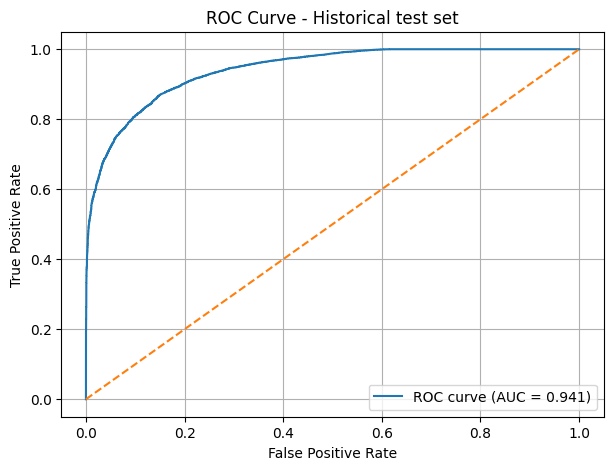

In [272]:
# In questa parte creo la curva ROC per valutare il modello
# sul test set del dataset storico.


# y_test contiene i valori reali della variabile target
# mentre proba_1 contiene le probabilità previste dal modello
# per la classe 1 (prenotazione confermata).

fpr_hist, tpr_hist, thresholds_hist = roc_curve(y_test, proba_1)


# Calcolo anche il valore AUC (Area Under the Curve).
# Questo valore riassume la qualità del modello:
# più è vicino a 1, migliore è il modello.

auc_hist = roc_auc_score(y_test, proba_1)


# Creo il grafico della curva ROC.

plt.figure(figsize=(7,5))

# Disegno la curva ROC usando il False Positive Rate (asse X)
# e il True Positive Rate (asse Y).

plt.plot(fpr_hist, tpr_hist, label=f"ROC curve (AUC = {auc_hist:.3f})")

# Aggiungo anche la linea diagonale di riferimento.
# Questa rappresenta il comportamento di un modello casuale.

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Historical test set")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Cella 8 — Confusion matrix — dataset storico

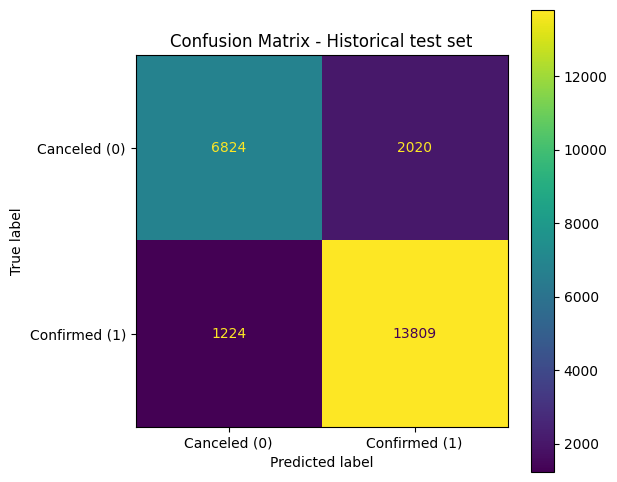

In [273]:
# Calcolo la confusion matrix usando i valori reali del test set (y_test)
# e le predizioni fatte dal modello (y_pred).
# La confusion matrix mostra quante predizioni sono corrette
# e quante sono sbagliate per ciascuna classe.

cm_hist = confusion_matrix(y_test, y_pred)


# Creo un oggetto ConfusionMatrixDisplay che mi permette
# di visualizzare la confusion matrix come grafico.

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hist,

    # Qui definisco le etichette delle classi.
    # 0 = prenotazione cancellata
    # 1 = prenotazione confermata
    display_labels=["Canceled (0)", "Confirmed (1)"]
)


# Creo la figura del grafico e imposto la dimensione.

fig, ax = plt.subplots(figsize=(6,6))


# Disegno la confusion matrix. colorbar=True aggiunge una barra laterale che indica
# l'intensità dei valori nelle celle.

disp.plot(ax=ax, colorbar=True)
plt.title("Confusion Matrix - Historical test set")
plt.show()

Cella 9 — Distribuzione delle probabilità — dataset storico

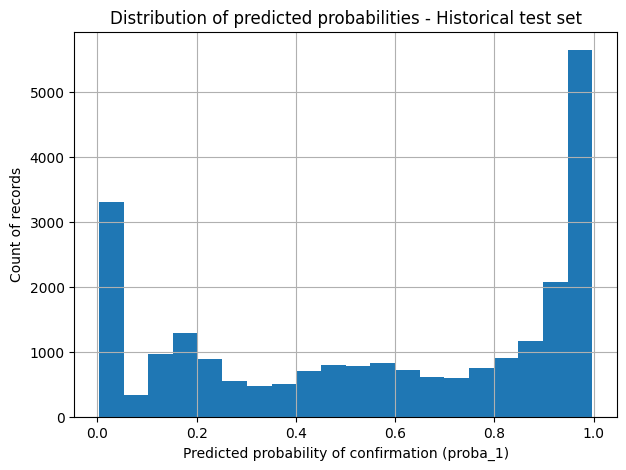

In [274]:
# In questo grafico voglio vedere come sono distribuite
# le probabilità previste dal modello per la classe 1 (prenotazione confermata).

plt.figure(figsize=(7,5))

# Creo un istogramma delle probabilità previste.
# proba_1 contiene la probabilità stimata dal modello che una prenotazione venga confermata.

plt.hist(proba_1, bins=20)

# Etichetta dell'asse X.
# Qui mostro il valore della probabilità prevista dal modello.

plt.xlabel("Predicted probability of confirmation (proba_1)")

# Etichetta dell'asse Y.
# Indica quanti record del dataset cadono in ciascun intervallo di probabilità.
plt.ylabel("Count of records")
plt.title("Distribution of predicted probabilities - Historical test set")
plt.grid(True)
plt.show()

Cella 10 — Grafico predizioni corrette / sbagliate — dataset storico

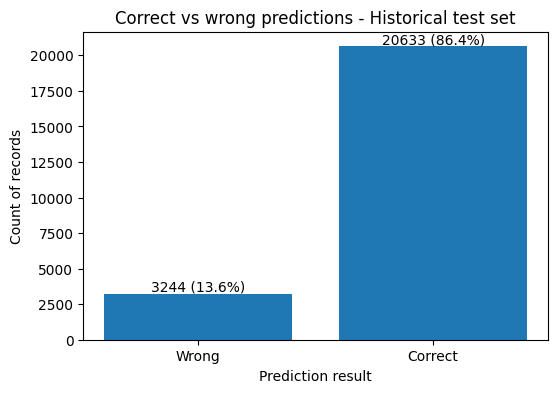

In [275]:
# Creo un piccolo dataframe che contiene:
# - il valore reale della prenotazione (booking_confirmed)
# - la predizione fatta dal modello

df_hist_eval = pd.DataFrame({
    "booking_confirmed": y_test.values,
    "prediction": y_pred
})


# Creo una nuova colonna che indica se la predizione è corretta.
# Se prediction è uguale al valore reale allora correct = 1,
# altrimenti correct = 0.

df_hist_eval["correct"] = (
    df_hist_eval["booking_confirmed"] == df_hist_eval["prediction"]
).astype(int)



# Conto quante predizioni sono corrette e quante sbagliate.

correct_counts_hist = df_hist_eval["correct"].value_counts().sort_index()

# Calcolo il numero totale di osservazioni.

total_hist = correct_counts_hist.sum()


# Creo il grafico a barre che mostra quante predizioni
# sono corrette e quante sono sbagliate.

plt.figure(figsize=(6,4))

bars = plt.bar(
    correct_counts_hist.index.astype(str),
    correct_counts_hist.values
)


# Etichetta asse X
# 0 = predizione sbagliata
# 1 = predizione corretta

plt.xlabel("Prediction result")


# Etichetta asse Y
# Numero di record nel dataset

plt.ylabel("Count of records")


# Titolo del grafico

plt.title("Correct vs wrong predictions - Historical test set")


# Rinomino le etichette dell'asse X per renderle più leggibili

plt.xticks(["0", "1"], ["Wrong", "Correct"])


# Sopra ogni barra mostro:
# - il numero di record
# - la percentuale rispetto al totale

for bar in bars:

    height = bar.get_height()

    percent = height / total_hist * 100

    label = f"{int(height)} ({percent:.1f}%)"

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        label,
        ha="center",
        va="bottom"
    )
plt.show()


# **PARTE 2    -     DATASET NUOVO (ANNO 2024)**



Cella 11 — caricamento dataset 2024

In [276]:

df_2024 = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kundanbedmutha/hotel-booking-reservation",
    "hotel_bookings_updated_2024.csv"
)

print(df_2024.shape)
df_2024.head()

Using Colab cache for faster access to the 'hotel-booking-reservation' dataset.
(119390, 33)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow


Cella 12 — preprocessing iniziale dataset 2024

In [277]:
df_2024_1 = df_2024.copy()

# Creo una copia del dataset 2024.
# In questo modo posso fare il preprocessing senza modificare
# il dataset originale.


# Rimuovo alcune colonne che non sono utili per il modello.
# Sono le stesse colonne che avevo eliminato anche nel dataset storico.

drop_cols_2024 = [
    "previous_bookings_not_canceled",
    "reservation_status_date",
    "reservation_status"
]

df_2024_1 = df_2024_1.drop(columns=drop_cols_2024, errors="ignore")


# Rimuovo le righe dove distribution_channel è "Undefined".
# Questo valore non rappresenta un vero canale di distribuzione.

if "distribution_channel" in df_2024_1.columns:
    df_2024_1 = df_2024_1[df_2024_1["distribution_channel"] != "Undefined"]


# Controllo la colonna country.
# Elimino le righe dove il paese è vuoto oppure mancante.

if "country" in df_2024_1.columns:
    df_2024_1 = df_2024_1[df_2024_1["country"].notna()]
    df_2024_1 = df_2024_1[df_2024_1["country"] != ""]


# In Dataiku avevo anche un controllo chiamato "CountryMeaning"
# che verificava se il paese fosse valido.
# Nel notebook non ho questo controllo automatico,
# quindi per ora mantengo semplicemente i valori non vuoti.


# Controllo la colonna children. Converto i valori in numerico
# e rimuovo quelli uguali a 10 che nel dataset sono considerati errori.

if "children" in df_2024_1.columns:
    df_2024_1["children"] = pd.to_numeric(df_2024_1["children"], errors="coerce")
    df_2024_1 = df_2024_1[df_2024_1["children"] != 10.0]


# Controllo la colonna babies.
# Elimino i valori 9 e 10 perché sono considerati valori anomali.

if "babies" in df_2024_1.columns:
    df_2024_1["babies"] = pd.to_numeric(df_2024_1["babies"], errors="coerce")
    df_2024_1 = df_2024_1[~df_2024_1["babies"].isin([9, 10])]


# Nella colonna agent possono esserci valori vuoti o non validi.
# Provo a convertire tutto in numerico e sostituisco i valori mancanti con 0.

if "agent" in df_2024_1.columns:
    df_2024_1["agent"] = pd.to_numeric(df_2024_1["agent"], errors="coerce").fillna(0).astype(int)


# Faccio la stessa cosa per la colonna company. Anche qui riempio i valori mancanti con 0.

if "company" in df_2024_1.columns:
    df_2024_1["company"] = pd.to_numeric(df_2024_1["company"], errors="coerce").fillna(0).astype(int)


# Controllo la dimensione del dataset dopo il preprocessing
# per vedere quante righe e colonne sono rimaste.

print("Dopo preprocessing iniziale 2024:", df_2024_1.shape)

df_2024_1.head()

Dopo preprocessing iniziale 2024: (118894, 30)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,3,No Deposit,0,0,0,Transient,0.0,0,0,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,4,No Deposit,0,0,0,Transient,0.0,0,0,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,0,No Deposit,0,0,0,Transient,75.0,0,0,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,0,No Deposit,304,0,0,Transient,75.0,0,0,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,0,No Deposit,240,0,0,Transient,98.0,0,1,Lucknow


Cella 13 — feature engineering dataset 2024

In [278]:
df_2024_2 = df_2024_1.copy()

# Creo una nuova copia del dataset 2024 dopo il preprocessing iniziale.
# In questa fase costruisco nuove variabili che possono aiutare
# il modello a capire meglio il comportamento delle prenotazioni.


# Creo la variabile target booking_confirmed.
# Nel dataset originale is_canceled vale:
# 1 = prenotazione cancellata
# 0 = prenotazione confermata
# Io voglio invece una colonna dove:
# 1 = prenotazione confermata
# 0 = prenotazione cancellata

df_2024_2["booking_confirmed"] = 1 - df_2024_2["is_canceled"]

# Normalizzo i nomi degli hotel per mantenere
# la stessa struttura del dataset storico.

df_2024_2["hotel"] = np.where(
    df_2024_2["hotel"].str.contains("City", case=False),
    "City Hotel",
    "Resort Hotel"
)


# Creo la variabile season partendo dal mese di arrivo.
# Raggruppo i mesi nelle quattro stagioni.

month_to_season = {
    "December": "1_winter",
    "January": "1_winter",
    "February": "1_winter",
    "March": "2_spring",
    "April": "2_spring",
    "May": "2_spring",
    "June": "3_summer",
    "July": "3_summer",
    "August": "3_summer",
    "September": "4_autumn",
    "October": "4_autumn",
    "November": "4_autumn"
}

df_2024_2["season"] = df_2024_2["arrival_date_month"].map(month_to_season).fillna("Other")


# Creo una variabile che indica se il soggiorno include almeno una notte nel weekend.

df_2024_2["weekend_flag"] = (df_2024_2["stays_in_weekend_nights"] > 0).astype(int)


# Raggruppo i paesi più frequenti e tutti gli altri li metto in "Other".
# Questo serve per ridurre il numero di categorie diverse.

top_countries = {"PRT", "GBR", "ESP", "IRL", "DEU", "FRA", "POL", "NLD", "BRA", "CN", "SWE"}

df_2024_2["country_group"] = np.where(
    df_2024_2["country"].isin(top_countries),
    df_2024_2["country"],
    "Other"
)


# Creo una variabile che indica se nella prenotazione sono presenti bambini.

df_2024_2["has_children"] = (df_2024_2["children"] > 0).astype(int)


# Calcolo il numero totale di notti del soggiorno.

df_2024_2["total_nights"] = df_2024_2["stays_in_week_nights"] + df_2024_2["stays_in_weekend_nights"]


# Creo una variabile categoriale che descrive la durata del soggiorno.

df_2024_2["stay_type"] = np.select(
    [
        df_2024_2["total_nights"] == 1,
        df_2024_2["total_nights"].between(2, 3),
        df_2024_2["total_nights"].between(4, 7),
        df_2024_2["total_nights"] >= 8
    ],
    ["1_night", "2_3_nights", "4_7_nights", "8plus_nights"],
    default="8plus_nights"
)


# Raggruppo il prezzo medio per notte in alcune categorie.

df_2024_2["adr_category"] = np.select(
    [
        df_2024_2["adr"] < 70,
        df_2024_2["adr"] < 120,
        df_2024_2["adr"] < 250
    ],
    ["cheap", "medium", "expensive"],
    default="luxury"
)


# Calcolo il numero totale di ospiti nella prenotazione.

df_2024_2["total_guests"] = df_2024_2["adults"] + df_2024_2["children"] + df_2024_2["babies"]


# Converto il mese di arrivo da testo a numero.

month_to_num = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

df_2024_2["arrival_month_num"] = df_2024_2["arrival_date_month"].map(month_to_num)


# Creo una data di arrivo completa nel formato YYYY-MM-DD.

df_2024_2["arrival_date"] = (
    df_2024_2["arrival_date_year"].astype(str) + "-" +
    df_2024_2["arrival_month_num"].astype(int).astype(str).str.zfill(2) + "-" +
    df_2024_2["arrival_date_day_of_month"].astype(int).astype(str).str.zfill(2)
)


# Raggruppo il lead_time in alcune fasce di giorni.
# Questo serve per rendere più semplice l'analisi.

def lead_group(x):
    if x <= 7:
        return "0-7"
    if x <= 30:
        return "8-30"
    if x <= 90:
        return "31-90"
    if x <= 180:
        return "91-180"
    if x <= 365:
        return "181-365"
    if x <= 600:
        return "366-600"
    return "600+"

df_2024_2["lead_time_group"] = df_2024_2["lead_time"].apply(lead_group)


# Creo una variabile che indica se la stanza assegnata è diversa da quella prenotata.

df_2024_2["room_changed"] = (
    df_2024_2["reserved_room_type"] != df_2024_2["assigned_room_type"]
).astype(int)


# Raggruppo alcuni agenti specifici e tutti gli altri li metto in "other_agent".

def agent_group(a):
    if a == 0:
        return "no_agent"
    if a == 9:
        return "agent_9"
    if a == 240:
        return "agent_240"
    if a == 1:
        return "agent_1"
    if a == 14:
        return "agent_14"
    if a == 7:
        return "agent_7"
    if a == 6:
        return "agent_6"
    return "other_agent"

df_2024_2["agent_group"] = df_2024_2["agent"].apply(agent_group)


# Creo una variabile che indica se la prenotazione è stata fatta tramite azienda.

df_2024_2["company_booking"] = (df_2024_2["company"] != 0).astype(int)


# Creo una versione testuale del numero del mese con due cifre.

df_2024_2["arrival_month_num_str"] = (
    df_2024_2["arrival_month_num"].astype(int).astype(str).str.zfill(2)
)


# Creo una variabile che indica se la prenotazione è stata in lista di attesa.

df_2024_2["has_waiting_list"] = (
    df_2024_2["days_in_waiting_list"] > 0
).astype(int)


# Dopo aver creato la variabile, la colonna originale non serve più.

df_2024_2 = df_2024_2.drop(columns=["days_in_waiting_list"], errors="ignore")


# Raggruppo il numero di modifiche della prenotazione.

df_2024_2["booking_changes_group"] = np.select(
    [
        df_2024_2["booking_changes"] == 0,
        df_2024_2["booking_changes"] == 1
    ],
    ["0_change", "1_change"],
    default="2+_change"
)


# Le colonne originali non servono più dopo il raggruppamento.

df_2024_2 = df_2024_2.drop(columns=["company", "booking_changes"], errors="ignore")


# Creo una variabile che indica se il cliente ha richiesto il parcheggio.

df_2024_2["needs_parking"] = (
    df_2024_2["required_car_parking_spaces"] > 0
).astype(int)


# Rimuovo la colonna originale perché non serve più.

df_2024_2 = df_2024_2.drop(columns=["required_car_parking_spaces"], errors="ignore")


# Raggruppo il numero di richieste speciali.

sr_2024 = df_2024_2["total_of_special_requests"]

df_2024_2["special_requests_group"] = np.select(
    [sr_2024 == 0, sr_2024 == 1, sr_2024 == 2, sr_2024 == 3],
    ["0_request", "1_request", "2_requests", "3_requests"],
    default="4+_requests"
)


# Dopo aver creato le variabili raggruppate, elimino le colonne originali che non servono più.

df_2024_2 = df_2024_2.drop(columns=["country", "agent", "total_of_special_requests"], errors="ignore")


# Creo una variabile che descrive la dimensione del gruppo di ospiti.

tg_2024 = df_2024_2["total_guests"]

df_2024_2["guest_group"] = np.select(
    [tg_2024 == 1, tg_2024 == 2, tg_2024 <= 4],
    ["single", "couple", "small_group"],
    default="large_group"
)


# Dopo aver creato guest_group, la colonna total_guests non serve più.

df_2024_2 = df_2024_2.drop(columns=["total_guests"], errors="ignore")


# Creo una variabile che descrive il tipo di viaggio.

df_2024_2["trip_type"] = np.select(
    [
        df_2024_2["stays_in_weekend_nights"] == 0,
        df_2024_2["stays_in_week_nights"] == 0
    ],
    ["business_trip", "weekend_trip"],
    default="mixed_trip"
)

# Creo una variabile che indica se il cliente ha cancellato prenotazioni in passato.
df_2024_2["previous_cancellation_group"] = np.select(
    [
        df_2024_2["previous_cancellations"] == 0,
        df_2024_2["previous_cancellations"] == 1,
        df_2024_2["previous_cancellations"] >= 2
    ],
    [
        "no_previous",
        "one_previous",
        "multiple_previous"
    ],
    default="multiple_previous"
)

df_2024_2 = df_2024_2.drop(columns=["previous_cancellations"], errors="ignore")


# Controllo la dimensione del dataset dopo la creazione di tutte le nuove feature.

print("Dopo feature engineering 2024:", df_2024_2.shape)

df_2024_2.head()

Dopo feature engineering 2024: (118894, 44)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent_group,company_booking,arrival_month_num_str,has_waiting_list,booking_changes_group,needs_parking,special_requests_group,guest_group,trip_type,previous_cancellation_group
0,Resort Hotel,0,342,2024,July,30,27,0,0,2,...,no_agent,0,07,0,2+_change,0,0_request,couple,business_trip,no_previous
1,Resort Hotel,0,737,2024,April,17,28,0,0,2,...,no_agent,0,04,0,2+_change,0,0_request,couple,business_trip,no_previous
2,Resort Hotel,0,7,2024,September,37,10,0,1,1,...,no_agent,0,09,0,0_change,0,0_request,single,business_trip,no_previous
3,Resort Hotel,0,13,2024,August,33,14,0,1,1,...,other_agent,0,08,0,0_change,0,0_request,single,business_trip,no_previous
4,Resort Hotel,0,14,2024,September,37,14,0,2,2,...,agent_240,0,09,0,0_change,0,1_request,couple,business_trip,no_previous


Cella 14 — drop finale colonne prima di applicare il modello

In [279]:
df_2024_3 = df_2024_2.copy()

# Creo una nuova copia del dataset dopo la fase di feature engineering.
# In questo passaggio preparo il dataset finale che verrà usato dal modello
# per fare le predizioni.


# Rimuovo alcune colonne che non voglio usare nel modello.
# Sono le stesse colonne che avevo eliminato anche nel dataset storico,
# quindi mantengo la stessa struttura delle feature usate durante il training.

drop_cols_final_2024 = [
    "adr_category",
    "babies",
    "children",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "arrival_date",
    "arrival_date_day_of_month",
    "arrival_month_num_str",
    "arrival_date_month",
    "arrival_date_year",
    "lead_time_group",
    "is_canceled"
]

df_2024_3 = df_2024_3.drop(columns=drop_cols_final_2024, errors="ignore")


# Controllo la dimensione finale del dataset che verrà usato per lo scoring.
# Questo dataset deve avere la stessa struttura delle feature
# usate durante l'addestramento del modello.

print("Dataset finale 2024 per scoring:", df_2024_3.shape)

df_2024_3.head()

Dataset finale 2024 per scoring: (118894, 32)


,hotel,lead_time,arrival_date_week_number,adults,meal,market_segment,distribution_channel,is_repeated_guest,reserved_room_type,assigned_room_type,...,room_changed,agent_group,company_booking,has_waiting_list,booking_changes_group,needs_parking,special_requests_group,guest_group,trip_type,previous_cancellation_group
0,Resort Hotel,342,30,2,BB,Direct,Direct,0,C,C,...,0,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous
1,Resort Hotel,737,17,2,BB,Direct,Direct,0,C,C,...,0,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous
2,Resort Hotel,7,37,1,BB,Direct,Direct,0,A,C,...,1,no_agent,0,0,0_change,0,0_request,single,business_trip,no_previous
3,Resort Hotel,13,33,1,BB,Corporate,Corporate,0,A,A,...,0,other_agent,0,0,0_change,0,0_request,single,business_trip,no_previous
4,Resort Hotel,14,37,2,BB,Online TA,TA/TO,0,A,A,...,0,agent_240,0,0,0_change,0,1_request,couple,business_trip,no_previous


Cella 15 — Creazione della primary key row_id

Aggiungo una colonna sequenziale per poter fare la join
tra dataset con target vero e dataset con predizioni.

In [280]:
df_2024_4 = df_2024_3.copy()

# Creo una nuova copia del dataset finale 2024.
# In questo passaggio aggiungo una chiave primaria artificiale
# che servirà più avanti per fare la join tra dataset diversi.


# Creo una colonna chiamata row_id con valori sequenziali.
# Ogni riga riceve un identificatore unico (0,1,2,3,...).
# Questo mi permette di collegare facilmente le predizioni
# del modello con il dataset originale che contiene il target reale.

df_2024_4["row_id"] = range(len(df_2024_4))


# Controllo la dimensione del dataset dopo l'aggiunta della chiave.

print("Dataset 2024 con row_id:", df_2024_4.shape)

df_2024_4.head()

Dataset 2024 con row_id: (118894, 33)


,hotel,lead_time,arrival_date_week_number,adults,meal,market_segment,distribution_channel,is_repeated_guest,reserved_room_type,assigned_room_type,...,agent_group,company_booking,has_waiting_list,booking_changes_group,needs_parking,special_requests_group,guest_group,trip_type,previous_cancellation_group,row_id
0,Resort Hotel,342,30,2,BB,Direct,Direct,0,C,C,...,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous,0
1,Resort Hotel,737,17,2,BB,Direct,Direct,0,C,C,...,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous,1
2,Resort Hotel,7,37,1,BB,Direct,Direct,0,A,C,...,no_agent,0,0,0_change,0,0_request,single,business_trip,no_previous,2
3,Resort Hotel,13,33,1,BB,Corporate,Corporate,0,A,A,...,other_agent,0,0,0_change,0,0_request,single,business_trip,no_previous,3
4,Resort Hotel,14,37,2,BB,Online TA,TA/TO,0,A,A,...,agent_240,0,0,0_change,0,1_request,couple,business_trip,no_previous,4


Cella 16 — Rimozione del target prima della predizione

Tolgo booking_confirmed per simulare un caso reale
in cui il modello deve predire senza conoscere il target.

In [281]:
df_2024_5 = df_2024_4.copy()

# Creo una nuova copia del dataset 2024.
# In questo passaggio preparo i dati per la fase di predizione del modello.


# Rimuovo temporaneamente la colonna target.
# Nella realtà, quando il modello fa una previsione,
# il valore reale della variabile target non è ancora conosciuto.
# Per questo motivo elimino booking_confirmed prima di applicare il modello.

df_2024_5 = df_2024_5.drop(columns=["booking_confirmed"], errors="ignore")


# Controllo la dimensione del dataset dopo aver rimosso il target.

print("Dataset 2024 senza target:", df_2024_5.shape)

df_2024_5.head()

Dataset 2024 senza target: (118894, 32)


,hotel,lead_time,arrival_date_week_number,adults,meal,market_segment,distribution_channel,is_repeated_guest,reserved_room_type,assigned_room_type,...,agent_group,company_booking,has_waiting_list,booking_changes_group,needs_parking,special_requests_group,guest_group,trip_type,previous_cancellation_group,row_id
0,Resort Hotel,342,30,2,BB,Direct,Direct,0,C,C,...,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous,0
1,Resort Hotel,737,17,2,BB,Direct,Direct,0,C,C,...,no_agent,0,0,2+_change,0,0_request,couple,business_trip,no_previous,1
2,Resort Hotel,7,37,1,BB,Direct,Direct,0,A,C,...,no_agent,0,0,0_change,0,0_request,single,business_trip,no_previous,2
3,Resort Hotel,13,33,1,BB,Corporate,Corporate,0,A,A,...,other_agent,0,0,0_change,0,0_request,single,business_trip,no_previous,3
4,Resort Hotel,14,37,2,BB,Online TA,TA/TO,0,A,A,...,agent_240,0,0,0_change,0,1_request,couple,business_trip,no_previous,4


Cella 17 — Controllo colonne tra training e dataset 2024

In [282]:
# Controllo il numero di colonne usate durante il training del modello.
# Questo mi serve per verificare che la struttura delle feature
# sia coerente con quella del dataset 2024.

print("Numero colonne training:", len(X.columns))


# Controllo il numero di colonne presenti nel dataset 2024
# dopo tutte le trasformazioni fatte finora.

print("Numero colonne dataset 2024:", len(df_2024_5.columns))


# Confronto le colonne dei due dataset. Qui stampo le colonne che esistono nel dataset 2024
# ma che non erano presenti nel dataset usato per addestrare il modello.

print("Colonne presenti nel 2024 ma non nel training:")
print(set(df_2024_5.columns) - set(X.columns))

Numero colonne training: 30
Numero colonne dataset 2024: 32
Colonne presenti nel 2024 ma non nel training:
{'row_id', 'city'}


Cella 18 — Applicazione del modello già addestrato al dataset 2024

Uso il modello allenato nella parte 1
per prevedere i risultati sul dataset 2024.

In [283]:
# Applico il modello già addestrato al dataset 2024.
# Uso la funzione score_new_data che ho definito prima,
# così posso riutilizzare lo stesso codice per qualsiasi dataset nuovo.

df_2024_pred = score_new_data(
    model=pipe,

    # Qui passo il dataset 2024 che voglio analizzare.
    # Questo dataset contiene tutte le feature necessarie
    # ma non contiene il target reale (booking_confirmed),
    # quindi simula una situazione reale di predizione.
    df_features=df_2024_5,

    # Qui specifico quali colonne devono essere usate dal modello.
    # Uso esattamente le stesse feature usate durante il training
    # per evitare errori o inconsistenze.
    feature_cols=X.columns,

    # Definisco la soglia di classificazione.
    # Se la probabilità di conferma è >= 0.375 → prediction = 1
    # altrimenti → prediction = 0.
    # Questa è la stessa soglia che avevo usato in Dataiku.
    threshold=0.375,

    # Qui indico che il dataset non contiene il target reale.
    # Quindi la funzione non calcolerà la colonna "correct".
    target_col=None
)


# Controllo la dimensione del dataset dopo aver aggiunto  le predizioni del modello.

print("Dataset 2024 con predizioni:", df_2024_pred.shape)


# Mostro alcune colonne principali per verificare il risultato:
# row_id → identificatore della riga
# proba_0 → probabilità che la prenotazione venga cancellata
# proba_1 → probabilità che la prenotazione venga confermata
# prediction → decisione finale del modello (0 o 1)

df_2024_pred[["row_id", "proba_0", "proba_1", "prediction"]].head()

Dataset 2024 con predizioni: (118894, 35)


,row_id,proba_0,proba_1,prediction
0,0,0.262504,0.737496,1
1,1,0.284273,0.715727,1
2,2,0.065665,0.934335,1
3,3,0.075384,0.924616,1
4,4,0.316000,0.684000,1


Cella 19 — Join tra predizioni e target vero

Unisco il dataset con prediction
al dataset originale che contiene booking_confirmed.

In [284]:
# In questo passaggio unisco il dataset che contiene le predizioni
# con il dataset che contiene il target reale (booking_confirmed).
# Uso la colonna row_id come chiave per collegare correttamente
# ogni riga con il suo risultato reale.

df_2024_joined = df_2024_pred.merge(

    # Qui prendo dal dataset originale solo due colonne:
    # row_id → chiave per fare la join
    # booking_confirmed → target reale della prenotazione
    df_2024_4[["row_id", "booking_confirmed"]],

    # Specifico che la join deve essere fatta usando row_id
    on="row_id",

    # Uso una left join.
    # Questo significa che mantengo tutte le righe del dataset
    # con le predizioni e aggiungo il target reale quando esiste.
    how="left"
)


# Controllo la dimensione del dataset dopo la join.

print("Dataset 2024 joinato:", df_2024_joined.shape)


# Mostro alcune colonne per verificare che la join sia corretta.
# row_id → identificatore della prenotazione
# proba_1 → probabilità che la prenotazione venga confermata
# prediction → decisione finale del modello
# booking_confirmed → valore reale della prenotazione

df_2024_joined[["row_id", "proba_1", "prediction", "booking_confirmed"]].head()

Dataset 2024 joinato: (118894, 36)


,row_id,proba_1,prediction,booking_confirmed
0,0,0.737496,1,1
1,1,0.715727,1,1
2,2,0.934335,1,1
3,3,0.924616,1,1
4,4,0.684000,1,1


Cella 20 — Verifica correttezza della predizione

Creo una colonna che vale:
1 se prediction == booking_confirmed
0 altrimenti

In [285]:
# In questo passaggio verifico se la predizione del modello è corretta.
# Confronto il valore predetto (prediction) con il valore reale
# della prenotazione (booking_confirmed).

df_2024_joined["correct"] = (
    df_2024_joined["prediction"] == df_2024_joined["booking_confirmed"]
).astype(int)


# Se la predizione è corretta → correct = 1
# Se la predizione è sbagliata → correct = 0
# Converto il risultato in intero per poter fare analisi più facilmente.


# Controllo quante predizioni sono corrette e quante sono sbagliate.

print(df_2024_joined["correct"].value_counts())


# Mostro alcune righe per verificare il risultato.
# row_id → identificatore della prenotazione
# prediction → previsione del modello
# booking_confirmed → valore reale
# correct → indica se la previsione è giusta (1) oppure sbagliata (0)

df_2024_joined[["row_id", "prediction", "booking_confirmed", "correct"]].head()

correct
1    102534
0     16360
Name: count, dtype: int64


,row_id,prediction,booking_confirmed,correct
0,0,1,1,1
1,1,1,1,1
2,2,1,1,1
3,3,1,1,1
4,4,1,1,1


Cella 21 — Valutazione finale sul dataset 2024

Calcolo metriche e confusion matrix sul dataset 2024



In [286]:
# In questo passaggio preparo le variabili necessarie
# per valutare le prestazioni del modello sul dataset 2024.

# y_true_2024 rappresenta il valore reale della prenotazione
# (1 = prenotazione confermata, 0 = prenotazione cancellata)

y_true_2024 = df_2024_joined["booking_confirmed"].astype(int)


# y_pred_2024 rappresenta la predizione fatta dal modello.

y_pred_2024 = df_2024_joined["prediction"].astype(int)


# proba_1_2024 rappresenta la probabilità stimata dal modello
# che la prenotazione venga confermata.

proba_1_2024 = df_2024_joined["proba_1"]


# Calcolo la matrice di confusione.
# Questa matrice mostra come il modello ha classificato i casi.

cm_2024 = confusion_matrix(y_true_2024, y_pred_2024)


# Trasformo la matrice di confusione in un DataFrame
# per renderla più leggibile.

cm_df_2024 = pd.DataFrame(
    cm_2024,
    index=["Actually 0", "Actually 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print(cm_df_2024)


# Calcolo alcune metriche principali di valutazione del modello.

# ROC AUC → quanto bene il modello separa le due classi
print("\nROC AUC:", roc_auc_score(y_true_2024, proba_1_2024))

# Accuracy → percentuale totale di predizioni corrette
print("Accuracy:", accuracy_score(y_true_2024, y_pred_2024))

# Precision → tra le prenotazioni previste come confermate, quante sono davvero confermate
print("Precision:", precision_score(y_true_2024, y_pred_2024))

# Recall → tra le prenotazioni davvero confermate, quante il modello riesce a trovare
print("Recall:", recall_score(y_true_2024, y_pred_2024))

# F1 score → equilibrio tra precision e recall
print("F1:", f1_score(y_true_2024, y_pred_2024))

            Predicted 0  Predicted 1
Actually 0        34177         9975
Actually 1         6385        68357

ROC AUC: 0.9405002965592106
Accuracy: 0.8623984389456154
Precision: 0.8726574069345862
Recall: 0.9145727970886516
F1: 0.8931235872845813


## Valutazione del modello sul dataset 2024

Il modello LightGBM addestrato sul dataset storico è stato applicato anche al **dataset delle prenotazioni del 2024**, che rappresenta dati nuovi e non utilizzati durante l’addestramento.

Questa valutazione permette di verificare se il modello mantiene buone prestazioni anche su dati più recenti.  
I grafici seguenti mostrano le principali metriche di performance del modello sul dataset 2024.

Cella 22 — Grafico corrette / sbagliate

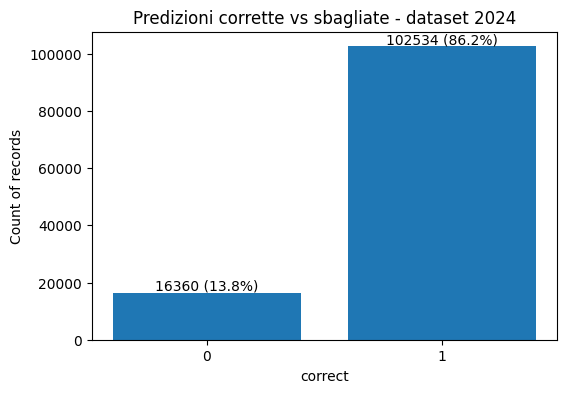

In [287]:
# Calcolo quante predizioni sono corrette e quante sono sbagliate.
# La colonna "correct" vale:
# 1 → predizione corretta
# 0 → predizione sbagliata

correct_counts = df_2024_joined["correct"].value_counts().sort_index()


# Calcolo il numero totale di record.
# Questo mi serve per poter calcolare anche la percentuale.

total = correct_counts.sum()


# Creo la figura del grafico.

plt.figure(figsize=(6,4))


# Creo il grafico a barre.
# Ogni barra rappresenta il numero di predizioni corrette o sbagliate.

bars = plt.bar(correct_counts.index.astype(str), correct_counts.values)

plt.xlabel("correct")
plt.ylabel("Count of records")
plt.title("Predizioni corrette vs sbagliate - dataset 2024")


# In questo ciclo aggiungo sopra ogni barra:
# il numero di record e la percentuale sul totale.

for bar in bars:

    # altezza della barra (numero di record)
    height = bar.get_height()

    # calcolo la percentuale
    percent = height / total * 100

    # creo la stringa da mostrare sopra la barra esempio: 12345 (84.3%)
    label = f"{int(height)} ({percent:.1f}%)"

    plt.text(
        bar.get_x() + bar.get_width()/2,   # centro della barra
        height,                            # posizione verticale
        label,
        ha='center',
        va='bottom'
    )
plt.show()

Cella 23 — Confusion matrix

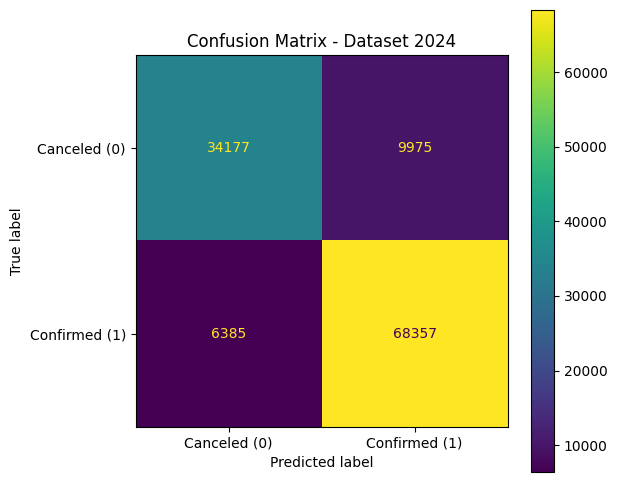

In [288]:
# Estraggo il valore reale della prenotazione dal dataset.
# booking_confirmed vale:
# 1 → prenotazione confermata
# 0 → prenotazione cancellata

y_true_2024 = df_2024_joined["booking_confirmed"].astype(int)


# Estraggo la predizione fatta dal modello.

y_pred_2024 = df_2024_joined["prediction"].astype(int)


# Calcolo la matrice di confusione.
# Questa matrice mostra come il modello ha classificato i casi.

cm = confusion_matrix(y_true_2024, y_pred_2024)


# Creo un oggetto per visualizzare la matrice in modo più leggibile.

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Canceled (0)", "Confirmed (1)"]
)


# Creo la figura del grafico.

fig, ax = plt.subplots(figsize=(6,6))


# Disegno la matrice di confusione.
# Il grafico mostra:
# - le predizioni corrette
# - le predizioni sbagliate
# - come il modello confonde le due classi

disp.plot(ax=ax, colorbar=True)
plt.title("Confusion Matrix - Dataset 2024")
plt.show()

Cella 24 — Curva ROC

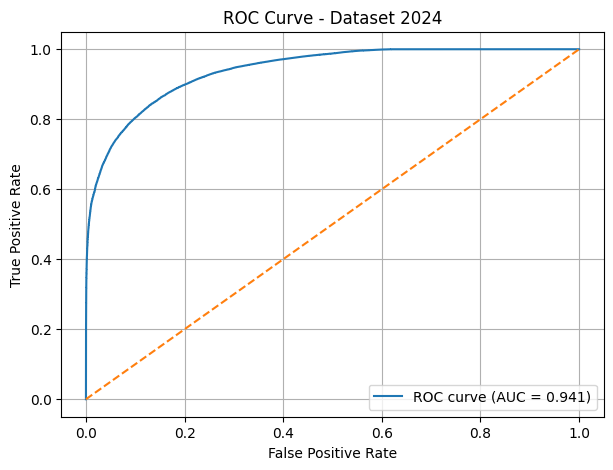

In [289]:
# Estraggo i valori reali della variabile target.
# booking_confirmed vale:
# 1 → prenotazione confermata
# 0 → prenotazione cancellata

y_true_2024 = df_2024_joined["booking_confirmed"].astype(int)


# Estraggo la probabilità stimata dal modello che la prenotazione
# venga confermata. Questa è la probabilità della classe 1.

y_score_2024 = df_2024_joined["proba_1"]


# Calcolo la curva ROC.
# La curva ROC mostra come cambia il rapporto tra:
# - True Positive Rate (sensibilità)
# - False Positive Rate
# quando cambia la soglia di classificazione.

fpr, tpr, thresholds = roc_curve(y_true_2024, y_score_2024)


# Calcolo anche il valore AUC (Area Under the Curve).
# Questo valore riassume la qualità del modello:
# 0.5 → modello casuale
# 1.0 → modello perfetto

auc_value = roc_auc_score(y_true_2024, y_score_2024)


# Creo il grafico della curva ROC.

plt.figure(figsize=(7,5))

# Disegno la curva ROC del modello
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_value:.3f})")

# Disegno anche la linea diagonale che rappresenta il comportamento di un classificatore casuale
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Dataset 2024")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Cella 25 — Distribuzione delle probabilità del modello

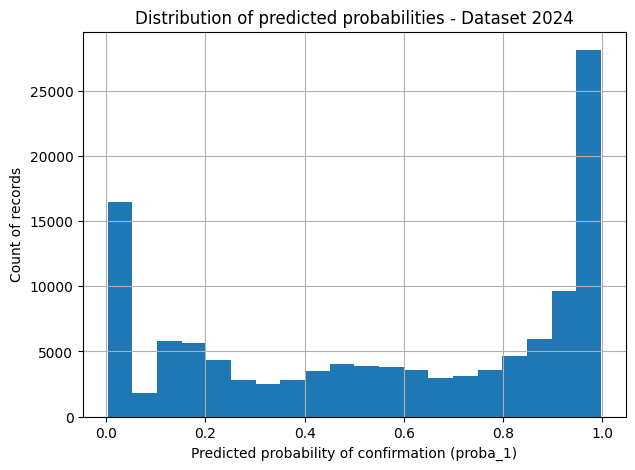

In [290]:
# Creo un grafico che mostra la distribuzione delle probabilità
# stimate dal modello per la classe "prenotazione confermata".

plt.figure(figsize=(7,5))

# Disegno un istogramma delle probabilità proba_1.
# Ogni barra mostra quanti record hanno una probabilità compresa in un certo intervallo.

plt.hist(df_2024_joined["proba_1"], bins=20)
plt.xlabel("Predicted probability of confirmation (proba_1)")
plt.ylabel("Count of records")
plt.title("Distribution of predicted probabilities - Dataset 2024")
plt.grid(True)
plt.show()

Cella 26 — Confronto storico vs 2024

In [291]:
# Creo una tabella che confronta le prestazioni del modello
# su due dataset diversi:
# 1) il test set storico usato durante il training
# 2) il dataset 2024 usato come dati nuovi (unseen data)

metrics_comparison = pd.DataFrame({

    # Elenco delle metriche che voglio confrontare
    "Metric": ["ROC AUC", "Accuracy", "Precision", "Recall", "F1"],


    # Qui calcolo le metriche sul test set storico.
    # Questo mi dice quanto bene il modello funziona
    # sui dati separati durante il training.

    "Historical test set": [
        roc_auc_score(y_test, proba_1),
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],


    # Qui calcolo le stesse metriche sul dataset 2024.
    # Questo dataset non è stato usato nel training,
    # quindi rappresenta una verifica su dati nuovi.

    "2024 dataset": [
        roc_auc_score(y_true_2024, proba_1_2024),
        accuracy_score(y_true_2024, y_pred_2024),
        precision_score(y_true_2024, y_pred_2024),
        recall_score(y_true_2024, y_pred_2024),
        f1_score(y_true_2024, y_pred_2024)
    ]
})


# Mostro la tabella finale con il confronto delle metriche.

metrics_comparison

,Metric,Historical test set,2024 dataset
0,ROC AUC,0.941291,0.940500
1,Accuracy,0.864137,0.862398
2,Precision,0.872386,0.872657
3,Recall,0.918579,0.914573
4,F1,0.894887,0.893124
